# SETUP AND LOAD

- Import libraries
- Configure display settings
- Load the dataset


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 👉 Update this path as needed
df = pd.read_csv(Path("/Users/mostaa/Downloads/movies.csv"))

In [2]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


# DATA CLEANING AND NORMALIZATION

- Normalize column names (lowercase, underscores)
- Convert numeric-like fields from strings (remove $ and commas)
- Keep the DataFrame sorted if desired (non-destructive preview)


In [3]:
# Normalize columns for easier handling in downstream steps
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
# Normalize numeric-like columns safely
for col in ['budget', 'gross', 'score', 'votes', 'runtime']:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)                    # Work around possible mixed types
            .str.replace(r"[\$,]", "", regex=True)  # Strip currency/commas
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# DATA QUALITY CHECKS

- Missing values: measure & drop rows with any NA (for a clean baseline)
- Duplicates: detect and remove
- Reset index
- Categorical normalization (rating label)


In [5]:
# Measure and drop rows with any NA (for a clean baseline)
missing_val = df.isnull().any(axis=1).sum()
missing_ratio = (missing_val / df.shape[0]) * 100
missing_ratio

# For a clean, analysis-ready subset, drop rows with any NA
df.dropna(inplace=True)

In [6]:
# Duplicates handling
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found!")

No duplicate rows found!


In [7]:
# Reset index after row drops
df.reset_index(drop=True, inplace=True)

In [8]:
# Normalize a categorical label (example: 'Unrated' → 'Not Rated')
df['rating'] = df['rating'].replace({
    'Unrated': 'Not Rated'})
df['rating'].value_counts()

rating
R            2597
PG-13        1729
PG            907
G             111
Not Rated      61
NC-17          12
TV-MA           2
Approved        1
X               1
Name: count, dtype: int64

# FEATURE ENGINEERING

- Return on Investment (ROI) = (gross - budget)/budget \* 100
- Profit = gross - budget
- These are the core business metrics for performance evaluation


In [9]:
# Calculate the Return on Investement (ROI) for each movie
df['roi'] = (df['gross'] - df['budget']) / df['budget'] * 100

# Calculate the Profit for each movie
df['profit'] = df['gross'] - df['budget']

# CORRELATION ANALYSIS

- Compute correlation matrix (numeric only)
- Identify strongest non-self correlations
- Use a heatmap for quick pattern recognition


In [10]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,year,score,votes,budget,gross,runtime,roi,profit
year,1.000000,0.056386,0.206021,0.327722,0.274321,0.075077,0.007513,0.237456
score,0.056386,1.000000,0.474256,0.072001,0.222556,0.414068,0.004068,0.243340
votes,0.206021,0.474256,1.000000,0.439675,0.614751,0.352303,0.017528,0.609203
budget,0.327722,0.072001,0.439675,1.000000,0.740247,0.318695,-0.018164,0.610530
gross,0.274321,0.222556,0.614751,0.740247,1.000000,0.275796,0.016289,0.984428
runtime,0.075077,0.414068,0.352303,0.318695,0.275796,1.000000,-0.024607,0.241554
roi,0.007513,0.004068,0.017528,-0.018164,0.016289,-0.024607,1.000000,0.023937
profit,0.237456,0.243340,0.609203,0.610530,0.984428,0.241554,0.023937,1.000000


In [11]:
# Flatten correlations to find strongest absolute pairs (exclude self-corr)
sorted_pairs = correlation_matrix.stack()

# Filter and view only stron correlations (abssolute value > 0.5 excluding self correlations)
strong_pairs = sorted_pairs[(abs(sorted_pairs) > 0.5) & (
    sorted_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)
strong_pairs

gross   profit    0.984428
budget  gross     0.740247
votes   gross     0.614751
budget  profit    0.610530
votes   profit    0.609203
dtype: float64

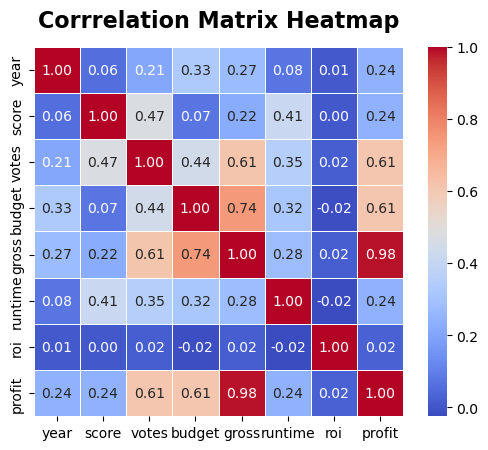

In [12]:
# Visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
            cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title("Corrrelation Matrix Heatmap",
          fontsize=16, fontweight='bold', pad=14)
plt.show()

# CORE VISUALIZATIONS

- Budget vs Gross (expect positive relationship)
- Votes vs Gross (popularity proxy vs. revenue)
- Total Gross by Year (macro trend; 2020 excluded if present)


Text(0, 0.5, 'Gross Revenue')

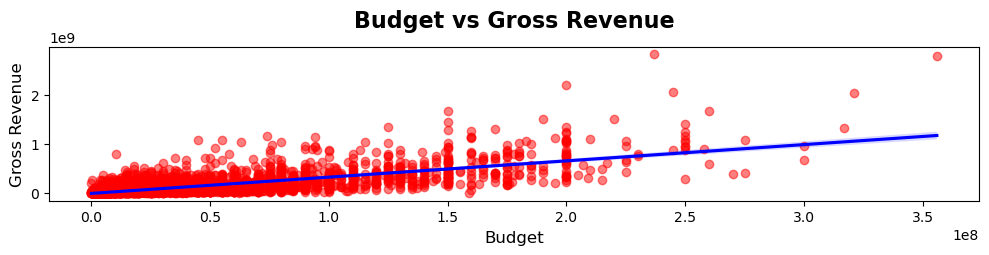

In [13]:
# Budget vs Gross Revenue
plt.figure(figsize=(12, 2))
sns.regplot(
    x='budget',
    y='gross',
    data=df,
    scatter_kws={
        'color': 'red',
        'alpha': 0.5
    },
    line_kws={
        'color': 'blue'
    }
)
plt.title("Budget vs Gross Revenue", fontsize=16, fontweight='bold', pad=14)
plt.xlabel("Budget", fontsize=12)
plt.ylabel("Gross Revenue", fontsize=12)

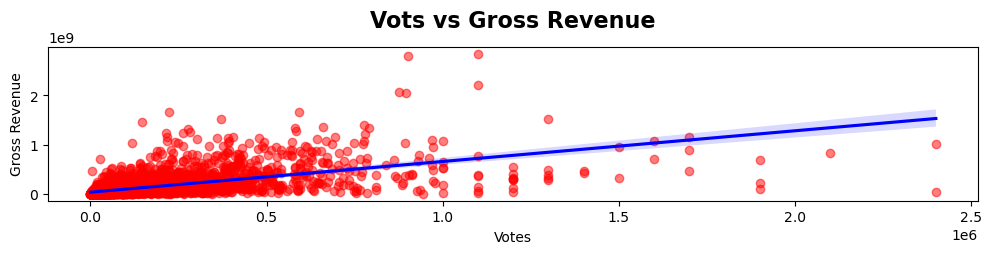

In [14]:
# Scatter Plot: Votes vs Gross Revenue
plt.figure(figsize=(12, 2))
sns.regplot(
    x='votes',
    y='gross',
    data=df,
    scatter_kws={'color': 'red', 'alpha': 0.5},
    line_kws={'color': 'blue'}
)

plt.title('Vots vs Gross Revenue', fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Votes", fontsize=10)
plt.ylabel("Gross Revenue", fontsize=10)
plt.show()

Text(0, 0.5, 'Total Gross Revenue')

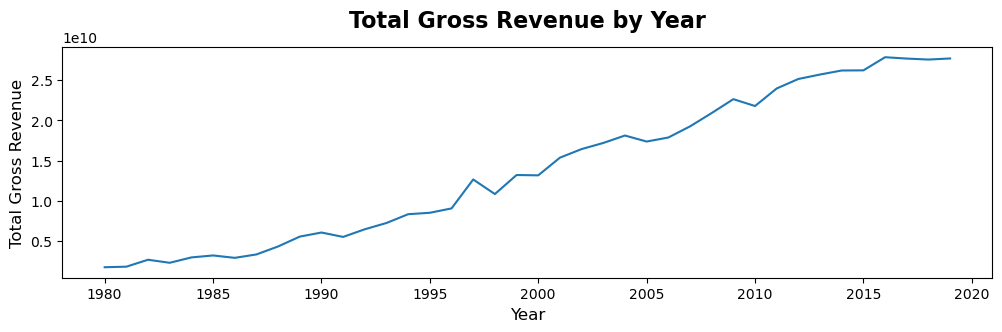

In [15]:
year_trend = df.groupby('year')['gross'].sum().reset_index()
year_trend = year_trend[year_trend['year'] != 2020]  # Exclude 2020 data

plt.figure(figsize=(12, 3))
sns.lineplot(
    x='year',
    y='gross',
    data=year_trend,
)
plt.title("Total Gross Revenue by Year",
          fontsize=16, fontweight='bold', pad=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Gross Revenue", fontsize=12)

# SUMMARY & BUSINESS-ORIENTED VIEWS

- High-level stats for quick readouts
- Top movies, top companies, genre ROI, and director highlights


### Summary Statistics


In [23]:
total_movies = df['name'].count()
unique_genres = df['genre'].drop_duplicates().count()
average_budget = df['budget'].mean()
average_gross = df['gross'].mean()
average_roi = df['roi'].mean()
strongest_correlation = list(strong_pairs.index)[0]

linebreak = 30*"="

print(f"""{linebreak} SUMMARY STATISTICS {linebreak}
  - Total Movies: {total_movies:,.0f}
  - Unique Genres: {unique_genres:,.0f}
  - Average Budget: ${average_budget:,.0f}
  - Average Gross Revenue: ${average_gross:,.0f}
  - Average ROI: {average_roi:.1f}%
  - Strongest Correlation: {
      strongest_correlation[0].title()} and {
          strongest_correlation[1].title()} with a correlation of {
              strong_pairs[strongest_correlation]*100:.1f}%
{linebreak*3}
    """)

============================== SUMMARY STATISTICS ==============================
  - Total Movies: 5,421
  - Unique Genres: 15
  - Average Budget: $36,009,170
  - Average Gross Revenue: $103,229,653
  - Average ROI: 572.7%
  - Strongest Correlation: Gross and Profit with a correlation of 98.4%
    


### Top 5 Movies by Gross Revenue


In [17]:
top_5_roi = df.sort_values(by='gross', ascending=False).head()
top_5_roi[['name', 'rating', 'genre', 'budget', 'gross']
          ].reset_index(drop=True)

,name,rating,genre,budget,gross
0,Avatar,PG-13,Action,237000000.0,2.847246e+09
1,Avengers: Endgame,PG-13,Action,356000000.0,2.797501e+09
2,Titanic,PG-13,Drama,200000000.0,2.201647e+09
3,Star Wars: Episode VII - The Force Awakens,PG-13,Action,245000000.0,2.069522e+09
4,Avengers: Infinity War,PG-13,Action,321000000.0,2.048360e+09


### Top Earning Companies by Total Gross Revenue


In [18]:
# Top Earning Companies by Total Gross Revenue
top_companies = df.groupby('company')[['gross']].sum(
).sort_values(by='gross', ascending=False)
top_companies.head(5)

,gross
company,
Warner Bros.,5.461096e+10
Universal Pictures,5.124111e+10
Columbia Pictures,4.235643e+10
Paramount Pictures,4.002170e+10
Twentieth Century Fox,3.954257e+10


### Most Successful Companies by Average Movie Revenue


In [19]:
# Most Successful Companies by Average Move Revenue
avg_gross_companies = (
    df.groupby('company')['gross']
    .mean()
    .sort_values(ascending=False)
)

# Convert Series to DataFrame for better visualization
avg_gross_companies = avg_gross_companies.reset_index()
avg_gross_companies.columns = ['company', 'avg_gross_revenue']
avg_gross_companies.head(5)

,company,avg_gross_revenue
0,Marvel Studios,1.255466e+09
1,Illumination Entertainment,1.097122e+09
2,Fairview Entertainment,9.665549e+08
3,B24,8.806815e+08
4,Avi Arad Productions,8.560852e+08


Which genres yield the highest ROI?


In [20]:
top_genres_roi = df.groupby('genre')['roi'].agg(
    ['mean', 'median']).sort_values(by='mean', ascending=False)
top_genres_roi.head(5)

,mean,median
genre,,
Horror,7667.151514,208.435407
Family,2013.018822,344.694169
Thriller,329.977546,270.223850
Animation,297.439888,191.990706
Drama,270.822576,52.643691


### Top Directors by Best Single-Movie Profit


In [21]:
top_directors = df[['director', 'name', 'profit']].loc[df.groupby(['director', 'name'])[
    'profit'].idxmax()].sort_values(by='profit', ascending=False).reset_index(drop=True)
top_directors.head(5)

,director,name,profit
0,James Cameron,Avatar,2.610246e+09
1,Anthony Russo,Avengers: Endgame,2.441501e+09
2,James Cameron,Titanic,2.001647e+09
3,J.J. Abrams,Star Wars: Episode VII - The Force Awakens,1.824522e+09
4,Anthony Russo,Avengers: Infinity War,1.727360e+09
